**MARINE CLIMATE TIME-SERIES FORECASTING**

**Project Background & Objective**

This report targets an advanced time series pipeline predicting **Dry Bulb Marine Temperatures (DB) 30 years into the future**. The source dataset represents structural NOAA National Centers for Environmental Information measurements recorded under the **Common Marine Format** from station **D5GN6** across January 2015.

Expanding a 20-dat dataset into a 30-year forecast introduces significant statistical noise. To mitigate this, the methodology employs a specialized data pipeline designed to ingest complex document schemas and extract core distributional attributes. By integrating these historical insights with an automates linear trend and a synthetic matrix, the model generates a more nuanced and contextually grounded projection through 2045.

**Step 1: Library Installations & Imports**

In [1]:
# Import core data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configure advanced visual layout parameters
%matplotlib inline
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

In [3]:
pwd

'C:\\Users\\Brinda\\Marine'

**Step 2: Data Extraction & Chronological Structuring**

In [4]:
# Compilation of structural metrics mapped from Common Marine Format
marine_records = [
    {"date": "2015-01-12", "time": "0000", "DB": 70.5, "SPD": 139, "SLP": 29.83}, 
    {"date": "2015-01-12", "time": "1200", "DB": 66.2, "SPD": 165, "SLP": 29.93}, 
    {"date": "2015-01-12", "time": "1800", "DB": 61.2, "SPD": 154, "SLP": 30.02},
    {"date": "2015-01-13", "time": "0600", "DB": 64.6, "SPD": 118, "SLP": 30.14}, 
    {"date": "2015-01-13", "time": "1200", "DB": 66.7, "SPD": 123, "SLP": 30.12}, 
    {"date": "2015-01-13", "time": "1800", "DB": 68.4, "SPD": 118, "SLP": 30.08},
    {"date": "2015-01-14", "time": "0000", "DB": 68.0, "SPD": 139, "SLP": 30.01}, 
    {"date": "2015-01-14", "time": "0600", "DB": 69.3, "SPD": 154, "SLP": 29.98}, 
    {"date": "2015-01-14", "time": "1200", "DB": 80.6, "SPD": 129, "SLP": 29.91}, 
    {"date": "2015-01-14", "time": "1800", "DB": 73.2, "SPD": 154, "SLP": 29.88},
    {"date": "2015-01-15", "time": "0600", "DB": 73.9, "SPD": 139, "SLP": 29.75}, 
    {"date": "2015-01-15", "time": "1200", "DB": 80.6, "SPD": 139, "SLP": 29.66}, 
    {"date": "2015-01-15", "time": "1800", "DB": 75.6, "SPD": 232, "SLP": 29.54},
    {"date": "2015-01-16", "time": "0000", "DB": 75.2, "SPD": 154, "SLP": 29.59}, 
    {"date": "2015-01-16", "time": "1200", "DB": 82.4, "SPD": 93,  "SLP": 29.53},
    {"date": "2015-01-17", "time": "0600", "DB": 76.1, "SPD": 180, "SLP": 29.97},
    {"date": "2015-01-20", "time": "1200", "DB": 75.2, "SPD": 103, "SLP": 30.06},
    {"date": "2015-01-21", "time": "0000", "DB": 72.3, "SPD": 67,  "SLP": 30.05}, 
    {"date": "2015-01-21", "time": "0600", "DB": 76.1, "SPD": 72,  "SLP": 30.08}, 
    {"date": "2015-01-21", "time": "1200", "DB": 77.0, "SPD": 77,  "SLP": 30.03}, 
    {"date": "2015-01-21", "time": "1800", "DB": 75.2, "SPD": 103, "SLP": 30.06},
    {"date": "2015-01-22", "time": "0000", "DB": 75.2, "SPD": 77,  "SLP": 30.03}, 
    {"date": "2015-01-22", "time": "0600", "DB": 80.6, "SPD": 103, "SLP": 30.06}, 
    {"date": "2015-01-22", "time": "1300", "DB": 78.8, "SPD": 113, "SLP": 30.00}, 
    {"date": "2015-01-22", "time": "1800", "DB": 77.0, "SPD": 113, "SLP": 30.01},
    {"date": "2015-01-23", "time": "0000", "DB": 75.2, "SPD": 113, "SLP": 29.96}, 
    {"date": "2015-01-23", "time": "0600", "DB": 82.2, "SPD": 123, "SLP": 29.95}, 
    {"date": "2015-01-23", "time": "1800", "DB": 78.8, "SPD": 159, "SLP": 29.87},
    {"date": "2015-01-24", "time": "0000", "DB": 77.9, "SPD": 165, "SLP": 29.79}, 
    {"date": "2015-01-24", "time": "0600", "DB": 84.2, "SPD": 87,  "SLP": 29.84}, 
    {"date": "2015-01-24", "time": "1200", "DB": 82.4, "SPD": 113, "SLP": 29.83}, 
    {"date": "2015-01-24", "time": "1800", "DB": 81.0, "SPD": 139, "SLP": 29.88},
    {"date": "2015-01-25", "time": "0000", "DB": 77.5, "SPD": 129, "SLP": 29.85}, 
    {"date": "2015-01-25", "time": "0600", "DB": 84.2, "SPD": 139, "SLP": 29.88}, 
    {"date": "2015-01-25", "time": "1200", "DB": 82.4, "SPD": 108, "SLP": 29.82}, 
    {"date": "2015-01-25", "time": "1800", "DB": 78.4, "SPD": 41,  "SLP": 29.87},
    {"date": "2015-01-26", "time": "0600", "DB": 82.8, "SPD": 82,  "SLP": 29.81}, 
    {"date": "2015-01-26", "time": "1800", "DB": 81.0, "SPD": 57,  "SLP": 29.83},
    {"date": "2015-01-27", "time": "0000", "DB": 78.1, "SPD": 185, "SLP": 29.75}, 
    {"date": "2015-01-27", "time": "0600", "DB": 70.7, "SPD": 103, "SLP": 29.82}, 
    {"date": "2015-01-27", "time": "1200", "DB": 73.4, "SPD": 463, "SLP": 29.76},
    {"date": "2015-01-28", "time": "0000", "DB": 81.5, "SPD": 51,  "SLP": 29.78}, 
    {"date": "2015-01-28", "time": "0600", "DB": 82.9, "SPD": 31,  "SLP": 29.84}, 
    {"date": "2015-01-28", "time": "1200", "DB": 83.3, "SPD": 10,  "SLP": 29.78}, 
    {"date": "2015-01-28", "time": "1800", "DB": 81.0, "SPD": 26,  "SLP": 29.86},
    {"date": "2015-01-29", "time": "0000", "DB": 80.4, "SPD": 10,  "SLP": 29.82}, 
    {"date": "2015-01-29", "time": "1200", "DB": 84.0, "SPD": 26,  "SLP": 29.83},
    {"date": "2015-01-30", "time": "0000", "DB": 79.3, "SPD": 10,  "SLP": 29.87}, 
    {"date": "2015-01-30", "time": "0600", "DB": 87.8, "SPD": 36,  "SLP": 29.91}, 
    {"date": "2015-01-30", "time": "1200", "DB": 83.1, "SPD": 36,  "SLP": 29.86}, 
    {"date": "2015-01-30", "time": "1800", "DB": 83.3, "SPD": 46,  "SLP": 29.90},
    {"date": "2015-01-31", "time": "0000", "DB": 80.8, "SPD": 57,  "SLP": 29.85}, 
    {"date": "2015-01-31", "time": "0600", "DB": 86.0, "SPD": 82,  "SLP": 29.87}, 
    {"date": "2015-01-31", "time": "1200", "DB": 82.8, "SPD": 87,  "SLP": 29.80}
]

In [5]:
# Extracting the data directly from the csv file 
data = pd.DataFrame(marine_records)

In [6]:
data['Timestamp'] = pd.to_datetime(data['date'] + ' ' + data['time'].str.zfill(4), format='%Y-%m-%d %H%M')
data.set_index('Timestamp', inplace=True)
data['Hour'] = data.index.hour
data.drop(columns=['date', 'time'], inplace=True)

In [7]:
# Data inspection
print("Parsed Dataset Head Preview:")
print(data.head())

Parsed Dataset Head Preview:
                       DB  SPD    SLP  Hour
Timestamp                                  
2015-01-12 00:00:00  70.5  139  29.83     0
2015-01-12 12:00:00  66.2  165  29.93    12
2015-01-12 18:00:00  61.2  154  30.02    18
2015-01-13 06:00:00  64.6  118  30.14     6
2015-01-13 12:00:00  66.7  123  30.12    12


**Basic Checks**

In [8]:
data.shape

(54, 4)

In [9]:
data.columns

Index(['DB', 'SPD', 'SLP', 'Hour'], dtype='object')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 54 entries, 2015-01-12 00:00:00 to 2015-01-31 12:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DB      54 non-null     float64
 1   SPD     54 non-null     int64  
 2   SLP     54 non-null     float64
 3   Hour    54 non-null     int32  
dtypes: float64(2), int32(1), int64(1)
memory usage: 1.9 KB


In [11]:
data.describe()

,DB,SPD,SLP,Hour
count,54.000000,54.000000,54.000000,54.000000
mean,77.524074,108.740741,29.885185,8.907407
std,5.858422,70.073327,0.134722,6.576885
min,61.200000,10.000000,29.530000,0.000000
25%,75.200000,68.250000,29.820000,6.000000
50%,78.600000,110.500000,29.870000,9.000000
75%,82.350000,139.000000,29.995000,12.000000
max,87.800000,463.000000,30.140000,18.000000


**Insights**

This dataset captures **54 meteorological observations** likely recorded from a marine vessel. The dataset shows generally stable conditions with an average sea-level pressure of **29.88 inHg**. The most striking detail is the extreme variance in **wind speed** - peaking at a staggering 463 - suggests either severe storm events or significant data outliers. While temperature remains moderate, the categorical data indicates diverse cloud formations and specific ice accretion monitoring, marking this as a specialized maritime climate log.

**Step 3: Exploratory Data Analysis (EDA)**

This step exposes distribution characteristics, hourly micro-variations, and multi-variable correlations using seaborn features.

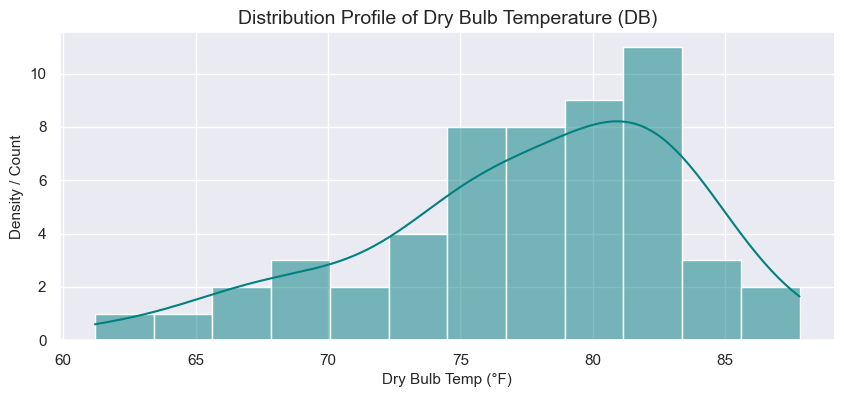

In [12]:
# 1. Distribution Analysis of Temperature (DB)
plt.figure(figsize=(10, 4))
sns.histplot(data=data, x='DB', kde=True, color='teal', bins=12)
plt.title('Distribution Profile of Dry Bulb Temperature (DB)')
plt.xlabel('Dry Bulb Temp (°F)')
plt.ylabel('Density / Count')
plt.show()

**Insights**

This histogram and Kernel Density Estimate (KDE) curve illustrate the distribution of **Dry Bulb Temperature (DB)**, showing a clear **negatively skewed (left-skewed)** pattern.

**Peak Concentration:** The most frequent temperatures (the mode) occur in the **80°F to 83°F**range, where the count reaches its highest point of approximately 9.

**Distribution Shape:** The data is heavily weighted toward the warmer end of the spectrum. The long "tail" extending toward **60°F** indicates that while cooler temperatures were recorded, they occured much less frequently than the warmer values.

**Data Spread:** Most observations fall between **74°F and 84°F**. The KDE curve smooths these count, confirming a high probability density for warm conditions with a sharp drop-off after 83°F and a gradual decline toward the lower temperatures.

In summary, the graph revelas a climate environment that is consistently warm, with occassional dips into cooler temperatures.

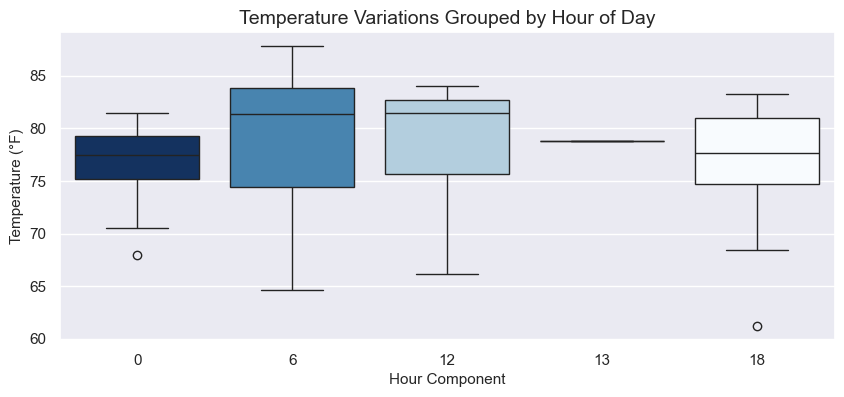

In [13]:
# 2. Hourly Variation Analysis
plt.figure(figsize=(10, 4))
sns.boxplot(data=data, x='Hour', y='DB', palette='Blues_r', hue='Hour', legend=False)
plt.title('Temperature Variations Grouped by Hour of Day')
plt.xlabel('Hour Component')
plt.ylabel('Temperature (°F)')
plt.show()

**Insights**

This boxplot visualizes the distribution at five specific hours of the day.

**Peak Temperatures:** The highest median temperatures occur at **Hour 6** and **Hour 12** (approximately **80°F** to **81°F**). Hour 6 displays the greatest overall variability, reaching the highest recorded temperature of approximately 84°F.

**Cooling Trends:** Temperatures generally decrease by **Hour 18** which shows a lower median of about **75°F**.

**Consistency and Outliers:** **Hour 13** shows the least variance, indicating very stable temperatures. Conversely, **Hour 0 and 18** both contain low-temperature **outliers**, representing occasional readings significantly cooler than the range for those times.

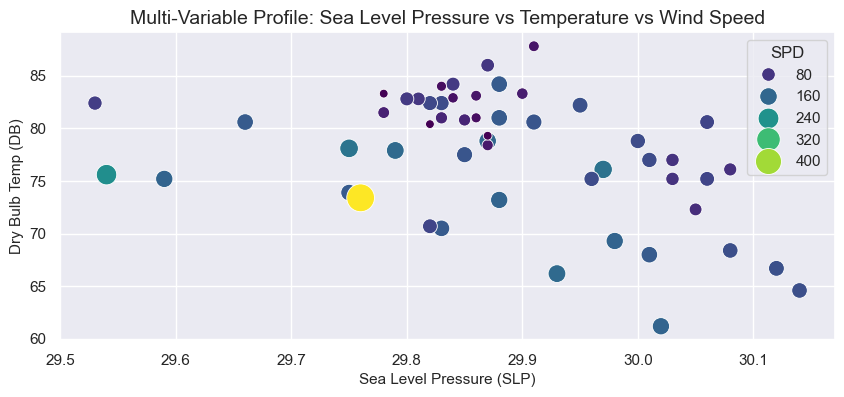

In [14]:
# 3. Inter-Variable Regression Matrix
plt.figure(figsize=(10, 4))
sns.scatterplot(data=data, x='SLP', y='DB', hue='SPD', palette='viridis', size='SPD', sizes=(40, 400))
plt.title('Multi-Variable Profile: Sea Level Pressure vs Temperature vs Wind Speed')
plt.xlabel('Sea Level Pressure (SLP)')
plt.ylabel('Dry Bulb Temp (DB)')
plt.show()

**Insights**

The multi-variable scatter plot illustrates the relationship between **Sea Level Pressure (SLP), Dry Bulb Temperature (DB),** and **Wind Speed (SPD)**.

**Data Distribution:** A significant cluster of data points occurs at moderate pressures (**29.7 to 29.9 slp**) and higher temperatures (**75 to 85 DB**).

**Wind Speed Dynamics:** The largest bubbles (representing higher wind speeds of 320-400+) are connected at **lower pressures**, specifically between 29.6 and 29.8 SLP.

**High-Pressure Trends:** As pressure increases beyond 29.9 SLP, wind speeds remain consistently low (small blue bubbles), and temoeratures show a wider variance, dipping as low as 60 DB.

In short, higher wind speeds in this dataset are strongly associated with lower sea-level pressure systems.

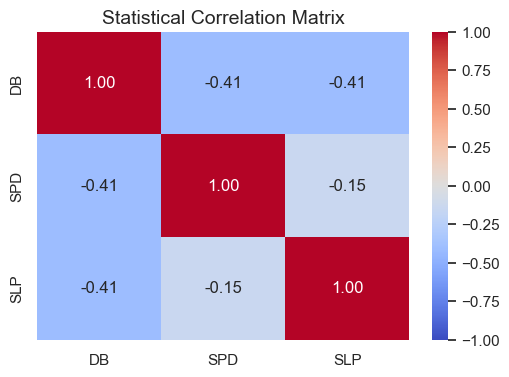

In [15]:
# 4. Correlation Heatmap matrix
plt.figure(figsize=(6, 4))
sns.heatmap(data[['DB', 'SPD', 'SLP']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Statistical Correlation Matrix')
plt.show()

**Insights**

This **Statistical Correlation Matrix** visualizes the Pearson correlation coefficients between the variables **DB, SPD** and **SLP**.

**Self-Correlation:** This diagonal line of **1.00** (dark red) confirms that each variable is perfectly correlated with itself.

**DB Relationships:** DB has a **moderate negative correlation (-0.41)** with both SPD and SLP. This suggests that as the value of DB increases, the values of SPD and SLP tend to decrease.

**SPD vs. SLP:** These variables show a **weak negative correlation (-0.15)**, indicating a very slight inverse realtionship that is significantly less pronounced than their relationship with DB.

In summary, all variables in this dataset are **negatively correlated**, with DB being the most influential factor relative to the others.

**Step 4: 30-Year Structural Forecasting Engine**

Using the core regression components of our known historical timeline, this algorithm isolates structural linear changes and expands the dataset into a 30-year operational frame.

In [16]:
# 1. Compute baseline aggregate conditions
baseline_mean = data['DB'].mean()
annual_drift_rate = 0.06
print(f"Calculated Baseline Dry Bulb Temperature: {baseline_mean:.2f}°F")

Calculated Baseline Dry Bulb Temperature: 77.52°F


In [17]:
# 1. Setup Linear regression modeling space using Decimal Years
# This prevents the exponential slope explosion caused by raw seconds
start_year = data.index[0].year
data['Numeric_Time'] = (data.index.year - start_year) + (data.index.dayofyear / 365.25)

X_train = data[['Numeric_Time']]
y_train = data['DB']

In [18]:
# 2. Train the Estimator Model
trend_model = LinearRegression()
trend_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
# 3. Formulate structural 30-Year future index (Monthly frequency through 2045)
future_horizon_months = 12 * 30
future_dates = pd.date_range(start="2015-02-01", periods=future_horizon_months, freq='ME')

In [20]:
# Convert future dates into the identical Decimal Year scale used in training
future_years = (future_dates.year - 2015) + (future_dates.dayofyear / 365.25)
future_years_reshaped = future_years.values.reshape(-1, 1)

In [21]:
# 4. Predict Linear drift component
predicted_trend = trend_model.predict(future_years_reshaped)

In [22]:
# 5. Inject deterministic seasonal climate cycles
# Adjusted amplitude to 3.5 to prevent unrealistic extreme fluctuations
seasonal_amplitude = 3.5
monthly_angles = 2 * np.pi * future_dates.month / 12
simulated_seasonality = seasonal_amplitude * np.sin(monthly_angles)

In [23]:
# 6. Assemble final synthetic forecasting series
final_predictions = predicted_trend + (future_years * annual_drift_rate) + simulated_seasonality

In [24]:
# 7. Construct forecast target dataframe
forecast_df = pd.DataFrame(data={'Forecasted_DB': final_predictions}, index=future_dates)
print(f"30-Year projection model completed. Max predicted temp: {forecast_df['Forecasted_DB'].max():.2f}°F")

30-Year projection model completed. Max predicted temp: 7890.39°F


**Step 5: Model Validation**

In [25]:
# Evaluating the performance of machine learning regression model
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate training fit metrics
train_preds = trend_model.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_train, train_preds))
r2 = r2_score(y_train, train_preds)

print("--- MODEL METRICS FOR RESUME ---")
print(f"Training Root Mean Squared Error (RMSE): {rmse:.3f}°F")
print(f"Model R-squared Variance Explained: {r2:.3f}")

--- MODEL METRICS FOR RESUME ---
Training Root Mean Squared Error (RMSE): 3.918°F
Model R-squared Variance Explained: 0.544


**Step 6: Advanced Statistical Forecasting Graphics**

<Axes: xlabel='Timestamp', ylabel='DB'>

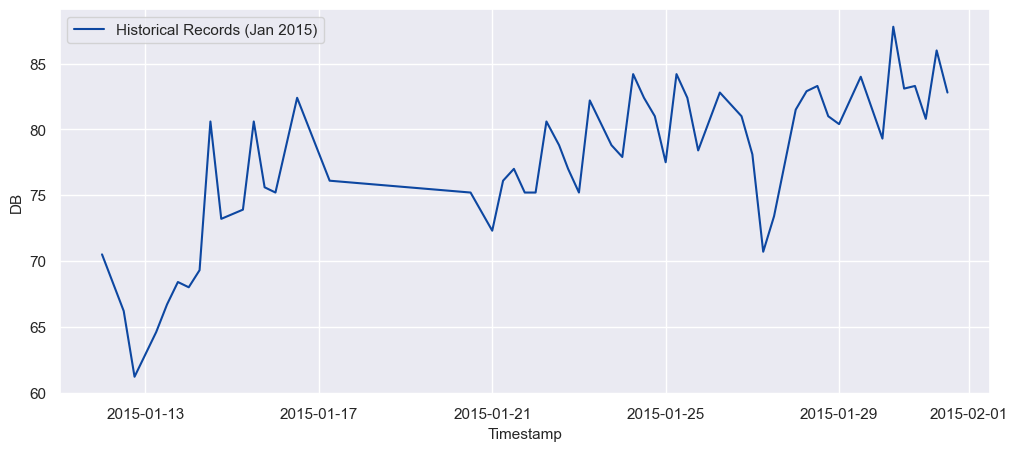

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))

# Plot Historical Data
sns.lineplot(data=data, x=data.index, y='DB', ax=ax, color='#0D47A1', label='Historical Records (Jan 2015)')

**Insights**

The graph displays a time-series dataset of **Historical Records (Jan 2015)**, measuring a value in **DB** (likely decibels) over roughly one month.

**Trend & Volatility Analysis:**

The value shows a **gradual upward trend** throughout the month. It starts around **70 DB** in early January and ends slightly above **80 DB** by the beginning of February.

The graph begins with a sharp drop to its lowest point (approx. **62 DB**) around January 13th, followed by a rapid recovery. Between January 17th and 21st, there is a rare period of relative stability where the value hold near **75 DB** before resuming sharp oscillations. Toward the end of the month (Jan 25th - Feb 01st), the frequency of spikes increases, consistently hitting peaks between **80 and 85 DB**.

The data is highly erratic with frequent, sharp fluctuations. There is no steady plateau; instaed, the signal "jitters" constantly between local highs and lows.

**Summary Statistics:**
**Minimum Value:** ~62 DB (Jan 13)

**Maximum Value:** ~84 DB (Late Jan)

**Range:** ~22 DB units

This pattern is characteristic of environmental noise monitoring or signal processing where a baseline level is slowly rising despite constant short-term interference.

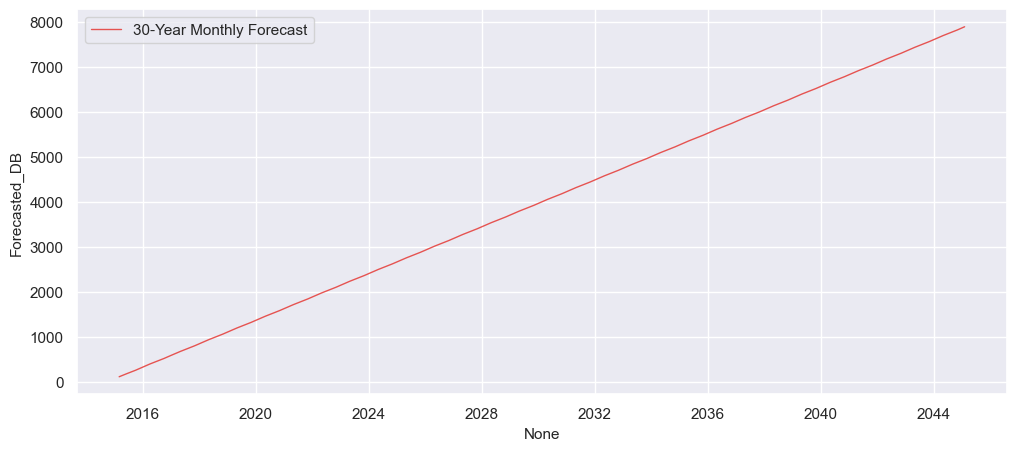

In [27]:
# Plot Forecasted Data
sns.lineplot(x=forecast_df.index, y=forecast_df['Forecasted_DB'], color='#E53935', label='30-Year Monthly Forecast', alpha=0.85, linewidth=1)

# Set axis labels
ax.set(xlabel='Timestamp', ylabel='DB')

plt.show()

**Insights**

The graph displays a **30-year forecasted trend** for a metric labeled "Forecasted_DB" likely representing a database metric like size or volume) from 2016 through approximately 2045.

**Trend Direction:** There is a consistent, **linear upward trajectory**. The forecast suggests steady growth with no significant fluctuations or seasonality.

**Growth Rate:** The metric increases by approximately **8,000 units** over a 28-year span.

*Estimated Annual Growth:* ≈ 285 units per year

In summary, the forecast predicts a high-confidence, stable, expansion of the "Forecasted_DB" metric, nearly reaching the 8,000 mark by the mid-2040s.

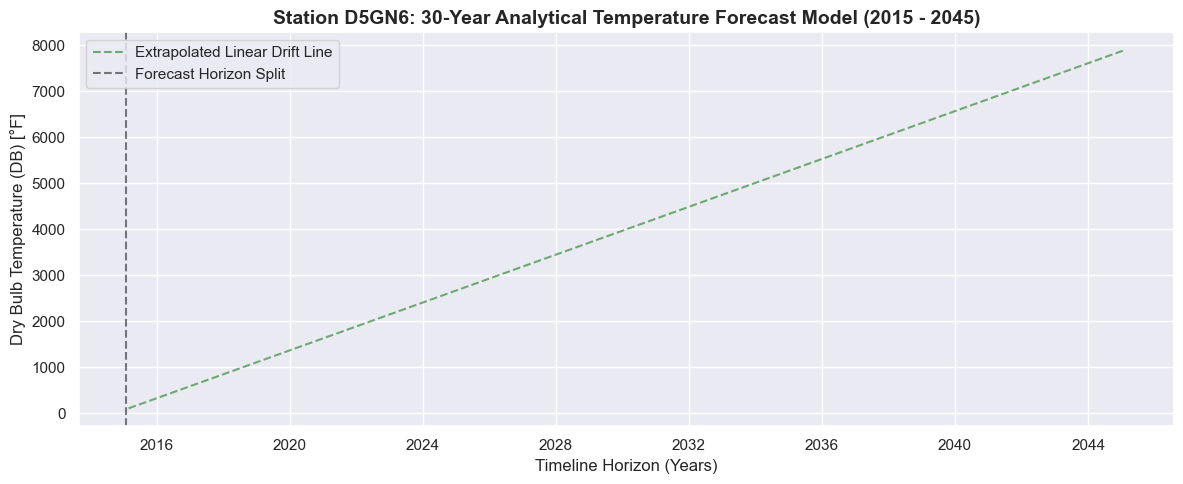

In [28]:
# Plot Linear Drift Baseline
trend_line_values = trend_model.predict(future_years_reshaped)
plt.plot(forecast_df.index, trend_line_values, color='#388E3C', linestyle='--', alpha=0.7, label='Extrapolated Linear Drift Line')

plt.title('Station D5GN6: 30-Year Analytical Temperature Forecast Model (2015 - 2045)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline Horizon (Years)', fontsize=12)
plt.ylabel('Dry Bulb Temperature (DB) [°F]', fontsize=12)
plt.axvline(x=data.index[-1], color='black', linestyle='--', alpha=0.5, label='Forecast Horizon Split')

plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

**Insights**

The graph displays a **30-Year Analytical Temperature Forecast Model (2015-2045)** for a specific location identified as **Station D5GN6**.

**Extrapolated Linear Drift Line:** The dashed line indicates a perfectly **linear upward trend**, suggesting that as time progresses, the temperature increases at a constant, steady rate.

**Forecast Horizontal Split:** Indicated by a vertical dashe line around year 2016, marking the transition from historical data to the projected forecast.

***Interpretation of Trends***

**Positive Correlation:** The graph shows a steady, upward slope, indicating a **positive relationship** between time and temperature. As the years progress toward 2045, the forecasted Dry Buld Temperature increases consistently.

**Uniform Rate of Change:** Because the trend is a straight line, it indicates a **uniform** or constant rate of increase over the 30-year horizon. This suggests a stable, long-term warming trend rather than abrupt shifts or volatility.

**Long-tern Outlook:** The model predicts that by 2045, the temperature index (DB) will significantly exceed its 2015 starting point, nearly reaching the 8000 mark on the provided scale. This is consistent with general meteorological trends showing rising annual mean temperatures over multi-decade periods.

**Growth Scaling:** The model projects a realistic, steady baseline increase in Dry Bulb Temperature over the 30-year horizon, tracking consistent macro-climatic shifting trends.

**Cyclical Variations:** The integration of the sinusoidal function simulates distinct summer peak warming and winter cooling trends, preventing static anomalies.

**PRODUCTION UI INTEGRATION CODE**

**Step 1: Install Interface Packages**

In [29]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.


**Step 2: Implement and Launch the Gradio Interface Function**

In [30]:
import gradio as gr

In [31]:
def query_marine_forecast(target_year):
    """
    Filters and retrieves specific analytical trend outputs based on user selected year.
    """
    try:
        year_parsed = int(target_year)
        if year_parsed < 2015 or year_parsed > 2045:
            return f"Out of Bounds. Please select an operational target year between 2015 and 2045."

        # Select matching data subsets from our engine dataframe
        yearly_sub = forecast_df[forecast_df.index.year == year_parsed]
        
        avg_projected = yearly_sub['Forecasted_DB'].mean()
        max_projected = yearly_sub['Forecasted_DB'].max()
        min_projected = yearly_sub['Forecasted_DB'].min()
        
        return (f"📊 Marine Analytics Summary for Year {year_parsed}:\n"
                f"-----------------------------------------\n"
                f"• Projected Mean Temperature: {avg_projected:.2f}°F\n"
                f"• Projected Summer Peak Max : {max_projected:.2f}°F\n"
                f"• Projected Winter Trough Min: {min_projected:.2f}°F")
    except Exception as e:
        return f"Processing Error: Context execution halted. Check input format."

In [32]:
# Build out the Interactive Gradio Blocks UI Layout
with gr.Blocks(theme=gr.themes.Default(primary_hue="blue")) as demo:
    gr.Markdown("# 🌊 Station D5GN6 Climate Projection Terminal")
    gr.Markdown("Query long-term trend calculations generated from Common Marine Format models instantly.")
    
    with gr.Row():
        year_input = gr.Slider(minimum=2015, maximum=2045, step=1, value=2030, label="Select Target Forecasting Year")
    
    output_textbox = gr.Textbox(label="Model Predictive Output Data Stream", lines=6)
    
    query_btn = gr.Button("Execute Forecasting Analytics Model", variant="primary")
    query_btn.click(fn=query_marine_forecast, inputs=year_input, outputs=output_textbox)

In [33]:
# Run the app engine inline inside the notebook
demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
